In [1]:
import numpy as np
import torchvision as thv

from common.nn.dataset.nn_dataset import NNDataset

from common.nn.enum.loss import Loss
from common.nn.enum.device import Device

from common.nn.params.nn_params import NNParams
from common.nn.params.nn_train_params import NNTrainParams
from common.nn.params.nn_model_params import NNModelParams

from common.nn.nn_model import NNModel

from common.nn.net.feed_fwd_nn import FeedFwdNN

from common.utils import Utils

In [2]:
DS_MEAN : float = 0.1307
DS_STD  : float = 0.3081

ds = NNDataset(
    ds_class=thv.datasets.MNIST
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD)
        ]
    )
)

print(
    ds.input_dim
    , ds.output_dim
    , len(ds.train_loader.dataset)
    , len(ds.val_loader.dataset)
    , len(ds.test_loader.dataset)
)

784 10 60000 1000 9000


In [3]:
n_epochs = 10
lrs = [0.001]
optims = ["adam"]

dropout_probs = [0.5]
hidden_dimss = [
    []
    , [500]
    , [1000]
    , [500, 1000]
]

models = [
    model
        for model in [
            NNModel(
                params=NNModelParams(device=Device.CPU, loss=Loss.CROSS_ENTROPY)
                , net=FeedFwdNN(
                    params=NNParams(
                        dropout_prob=dropout_prob
                        , hidden_dims=hidden_dims
                        , input_dim=ds.input_dim
                        , output_dim=ds.output_dim
                    )
                )
            )
                for dropout_prob in dropout_probs
                for hidden_dims in hidden_dimss
        ]
]

train_params = [
    train_param
        for train_param in [
            NNTrainParams(
                n_epochs=n_epochs
                , val_loader=ds.val_loader
                , train_loader=ds.train_loader
            )
        ]
]

runs = [
    run for run in [
        model.train(params=train_param)
            for model in models
            for train_param in train_params
    ]
]

[+] id: 8289c3fa6218ba68596044bfa832c9a2
[-] model_params: 
    [+] loss: cross_entropy
    [+] device: cpu
[-] net_params: 
    [+] dims: [784, 10]
    [+] dropout_prob: 0.5
    [+] activation_fn: leaky_relu
[-] train_params: 
    [+] n_epochs: 10
    [-] optim_params: 
        [+] lr_start: 0.9
        [+] momentum: (0.9, 0.999)
        [+] optim: adam
        [+] weight_decay: 0.0005
    [-] scheduler_params: 
        [+] factor: 0.9
        [+] patience: 5
        [+] threshold: 0.0001


[+] Training: 100%|██████████| 10/10 [00:32<00:00,  3.26s/it, error=0.2270, lr=0.9000]



[+] id: 816a66691e90ec1ab35e2c6b9604a99d
[-] model_params: 
    [+] loss: cross_entropy
    [+] device: cpu
[-] net_params: 
    [+] dims: [784, 500, 10]
    [+] dropout_prob: 0.5
    [+] activation_fn: leaky_relu
[-] train_params: 
    [+] n_epochs: 10
    [-] optim_params: 
        [+] lr_start: 0.9
        [+] momentum: (0.9, 0.999)
        [+] optim: adam
        [+] weight_decay: 0.0005
    [-] scheduler_params: 
        [+] factor: 0.9
        [+] patience: 5
        [+] threshold: 0.0001


[+] Training: 100%|██████████| 10/10 [00:55<00:00,  5.59s/it, error=0.3080, lr=0.9000]



[+] id: 1bb75d1a921bb7007e23861f015cbd77
[-] model_params: 
    [+] loss: cross_entropy
    [+] device: cpu
[-] net_params: 
    [+] dims: [784, 1000, 10]
    [+] dropout_prob: 0.5
    [+] activation_fn: leaky_relu
[-] train_params: 
    [+] n_epochs: 10
    [-] optim_params: 
        [+] lr_start: 0.9
        [+] momentum: (0.9, 0.999)
        [+] optim: adam
        [+] weight_decay: 0.0005
    [-] scheduler_params: 
        [+] factor: 0.9
        [+] patience: 5
        [+] threshold: 0.0001


[+] Training: 100%|██████████| 10/10 [01:18<00:00,  7.88s/it, error=0.2500, lr=0.9000]



[+] id: 910703b2463b98293d8d5af25ed7800b
[-] model_params: 
    [+] loss: cross_entropy
    [+] device: cpu
[-] net_params: 
    [+] dims: [784, 500, 1000, 10]
    [+] dropout_prob: 0.5
    [+] activation_fn: leaky_relu
[-] train_params: 
    [+] n_epochs: 10
    [-] optim_params: 
        [+] lr_start: 0.9
        [+] momentum: (0.9, 0.999)
        [+] optim: adam
        [+] weight_decay: 0.0005
    [-] scheduler_params: 
        [+] factor: 0.9
        [+] patience: 5
        [+] threshold: 0.0001


[+] Training: 100%|██████████| 10/10 [01:40<00:00, 10.09s/it, error=0.6780, lr=0.9000]

In [5]:
top_runs = [
    run for run in sorted(
        runs
        , key=lambda run: min(
            run.idps, key=lambda idp: idp.val_edp.error
        ).val_edp.error
    )[:3]
]

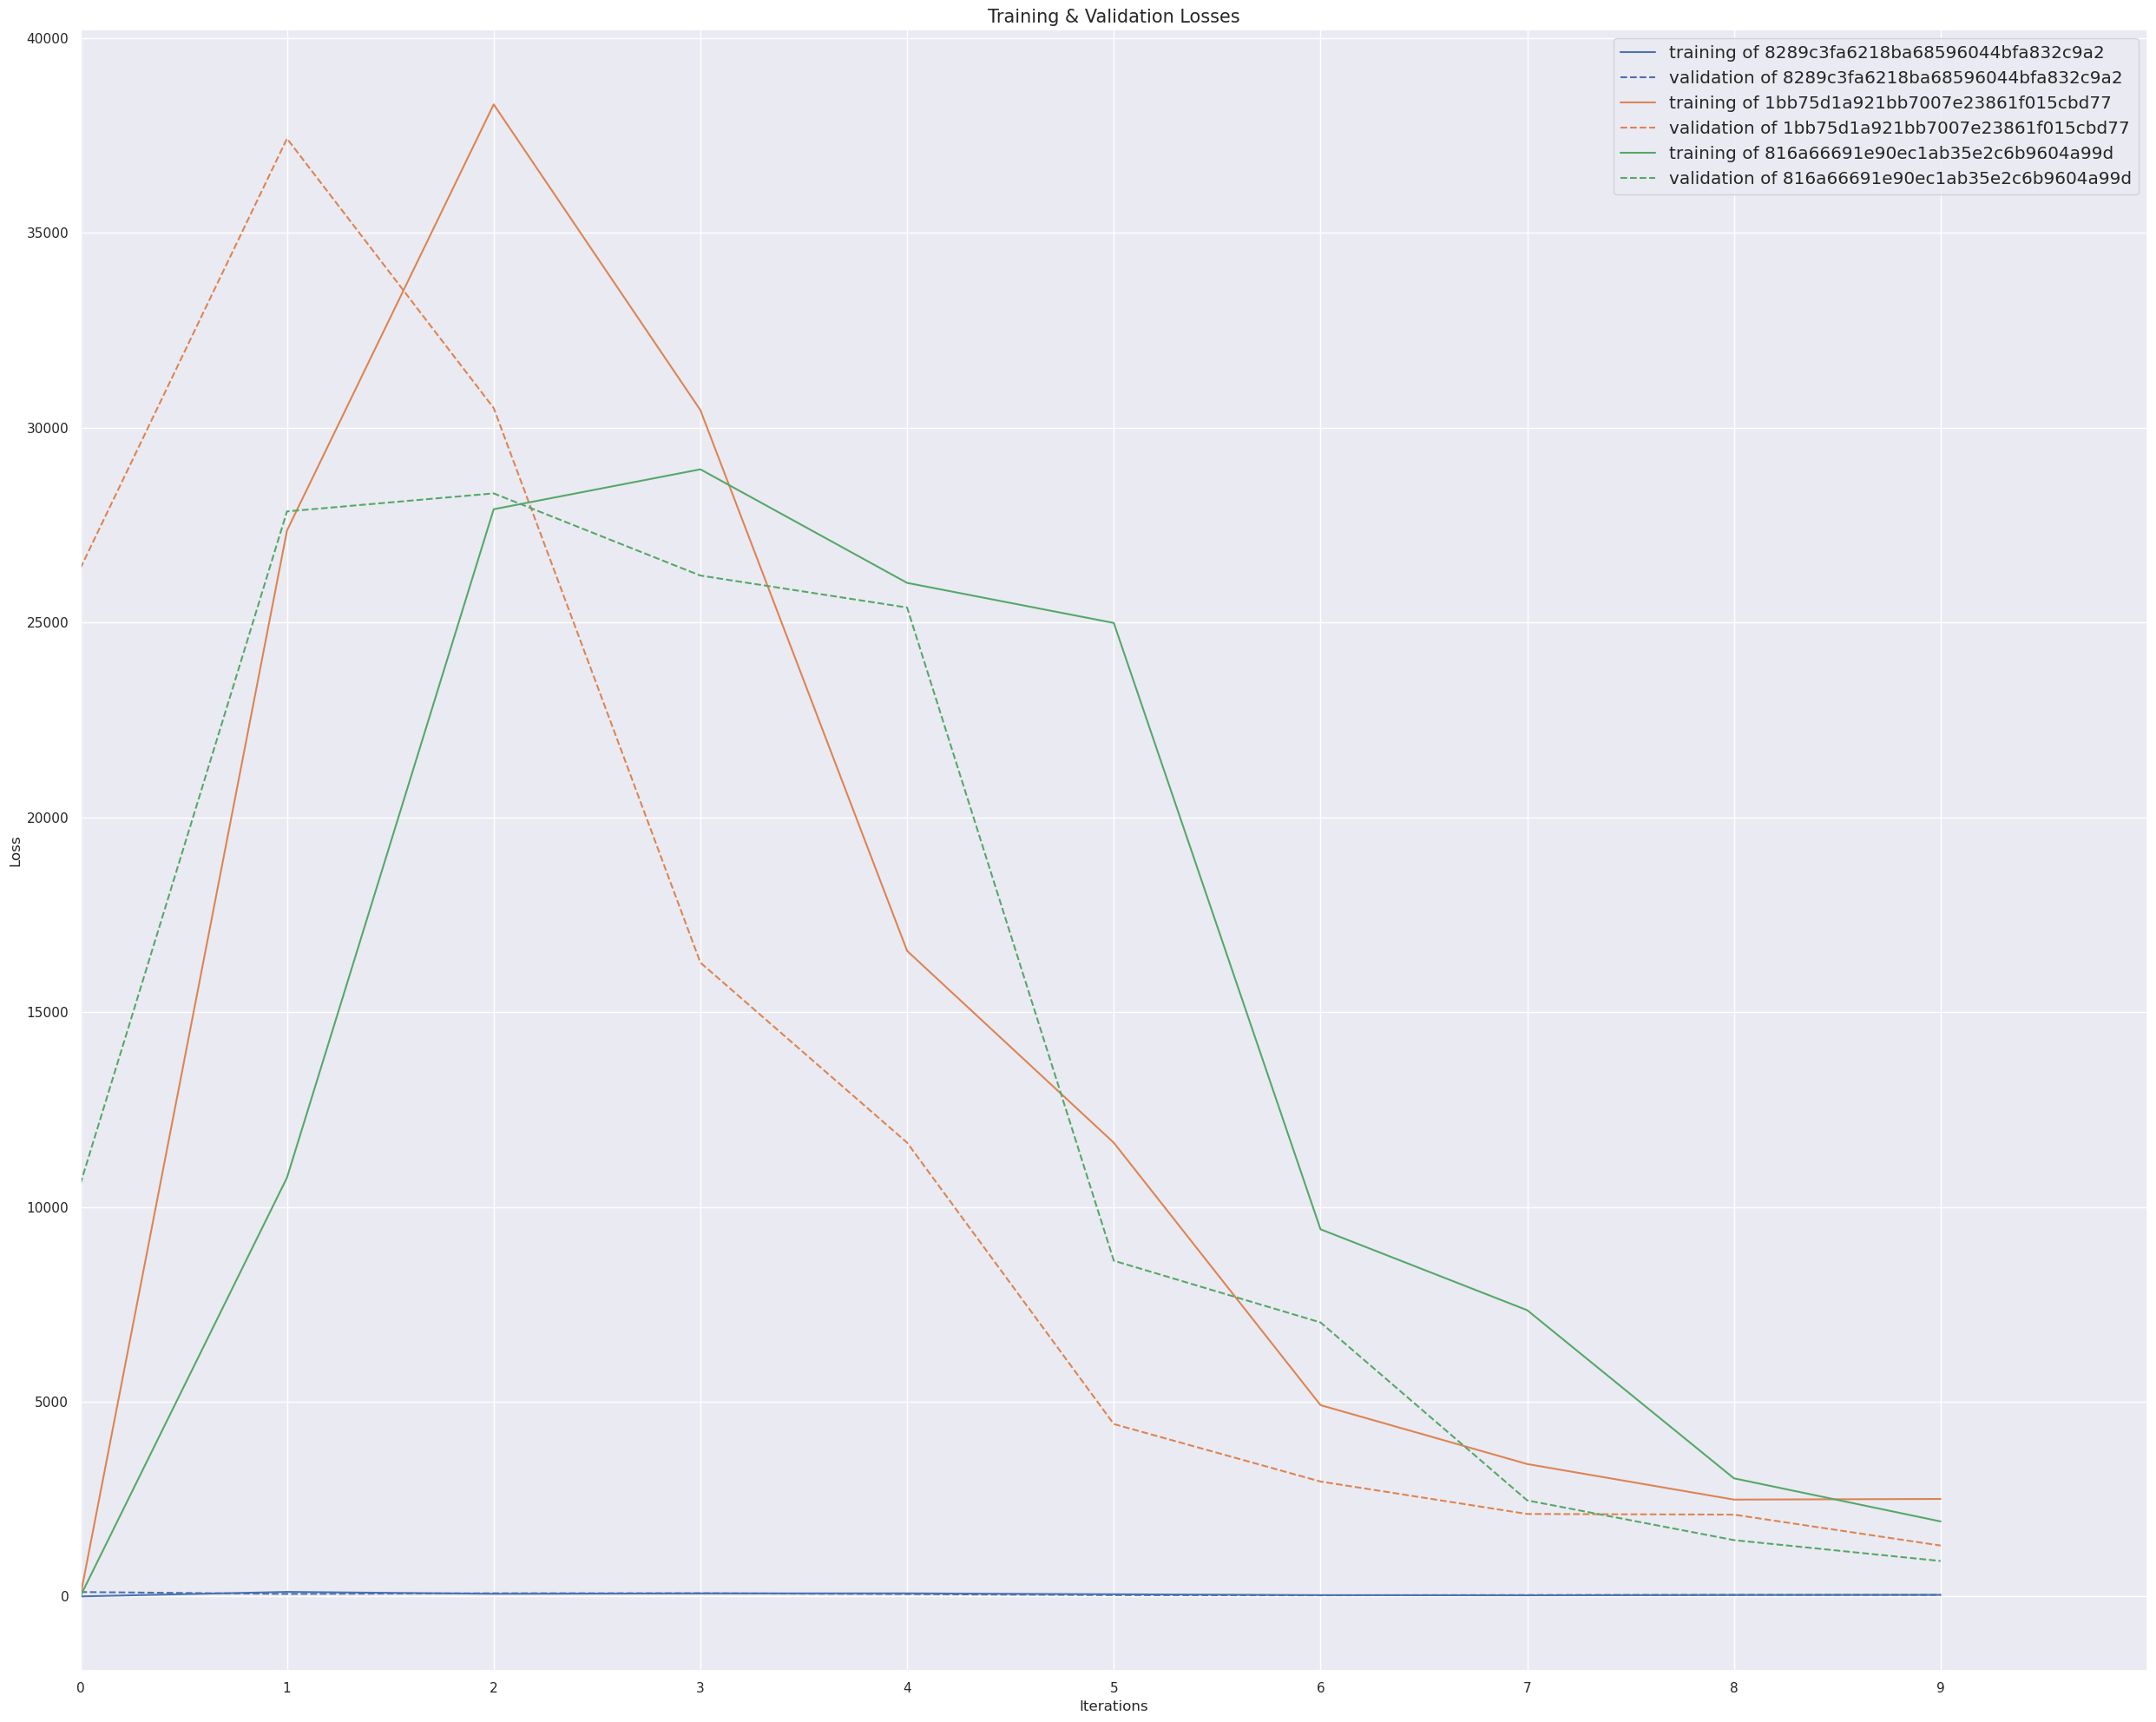

In [6]:
Utils.multi_line_plot(
    x_ticks_inc=1
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Losses"
    , x=[idp.iter_idx for idp in top_runs[0].idps]
    , yss_legend=[[f"{loss_type} of {run.id}" for loss_type in ["training", "validation"]] for run in top_runs]
    , yss=[[[idp.train_edp.loss for idp in run.idps], [idp.val_edp.loss for idp in run.idps]] for run in top_runs]
)

/usr/src/app/image_classification-mnist-ffnn-pytorch/common/utils.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


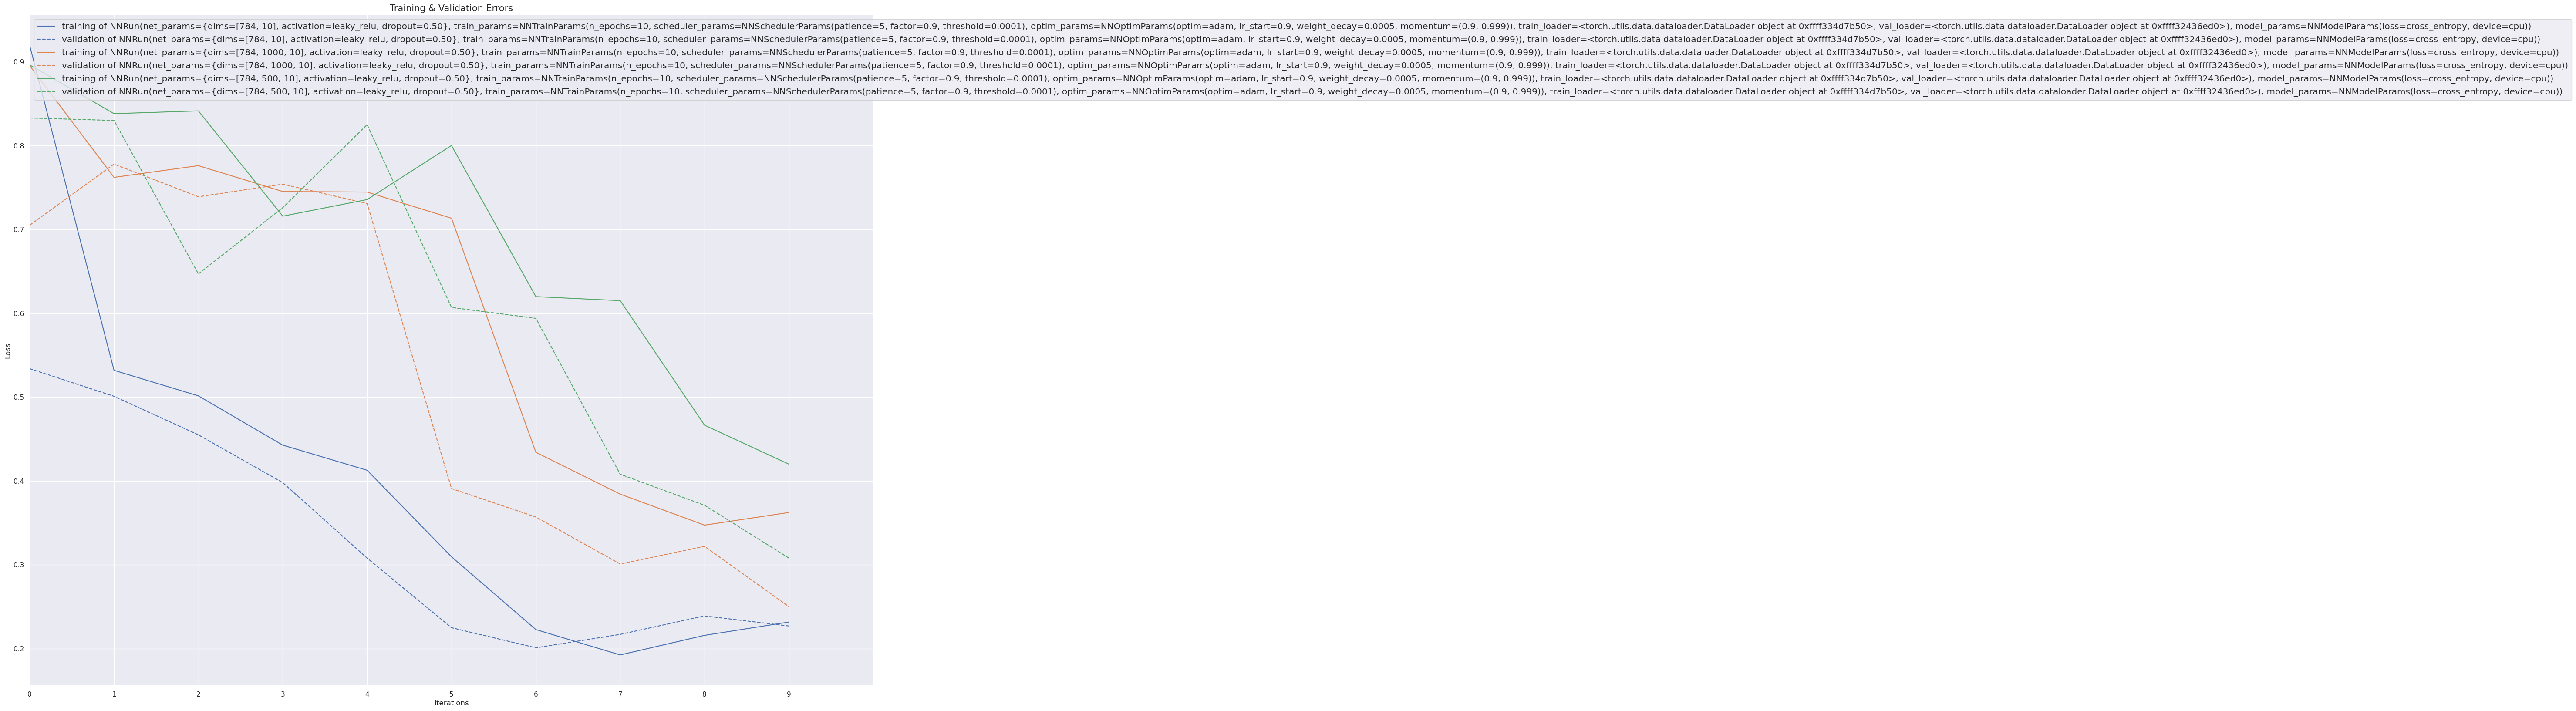

In [9]:
Utils.multi_line_plot(
    x_ticks_inc=1
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Errors"
    , x=[idp.iter_idx for idp in top_runs[0].idps]
    , yss_legend=[[f"{err_type} of {run.id}" for err_type in ["training", "validation"]] for run in top_runs]
    , yss=[[[idp.train_edp.error for idp in run.idps], [idp.val_edp.error for idp in run.idps]] for run in top_runs]
)

In [10]:
print(f"best model is {top_runs[0].id} which achieves validation error of {min(top_runs[0].idps, key=lambda idp: idp.val_edp.error).val_edp.error:.4f}")

best model is 8289c3fa6218ba68596044bfa832c9a2 which achieves validation error of 0.2010
